
Training XGBoost on AAPL...
AAPL: loaded from cache (1883 rows)

  XGBoost — AAPL
  RMSE               : 22.0153
  MAE                : 15.9122
  MAPE               : 6.04%
  Directional Acc.   : 53.3%


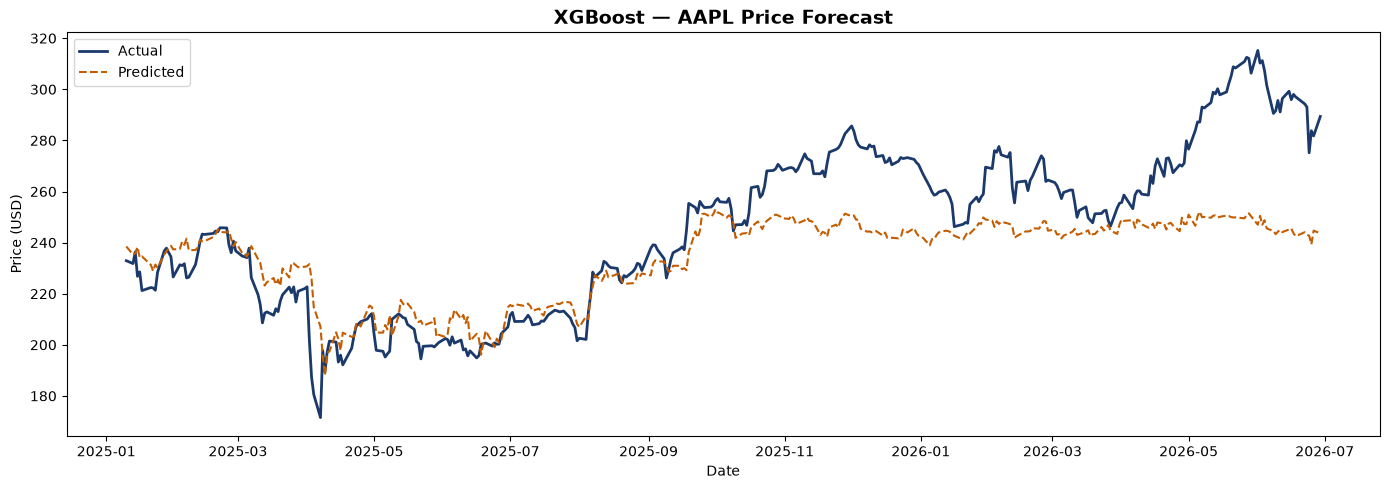

Chart saved to outputs/figures/AAPL_XGBoost.png


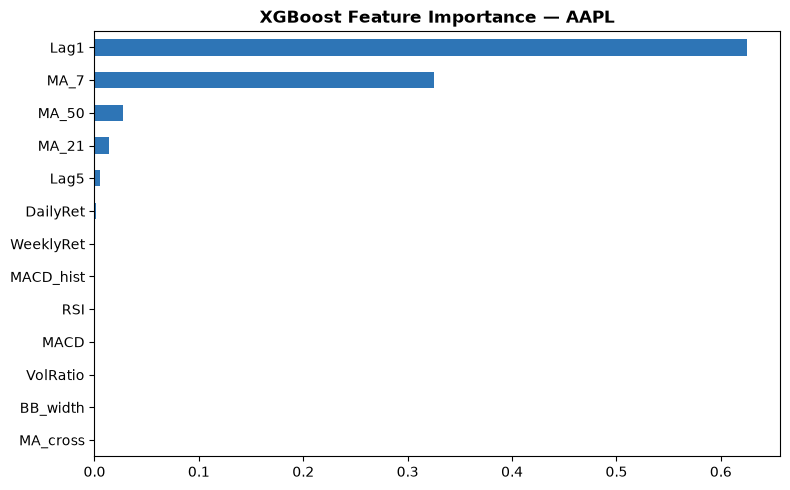


Training XGBoost on MSFT...
MSFT: loaded from cache (1883 rows)

  XGBoost — MSFT
  RMSE               : 39.2803
  MAE                : 29.2616
  MAPE               : 6.09%
  Directional Acc.   : 47.8%


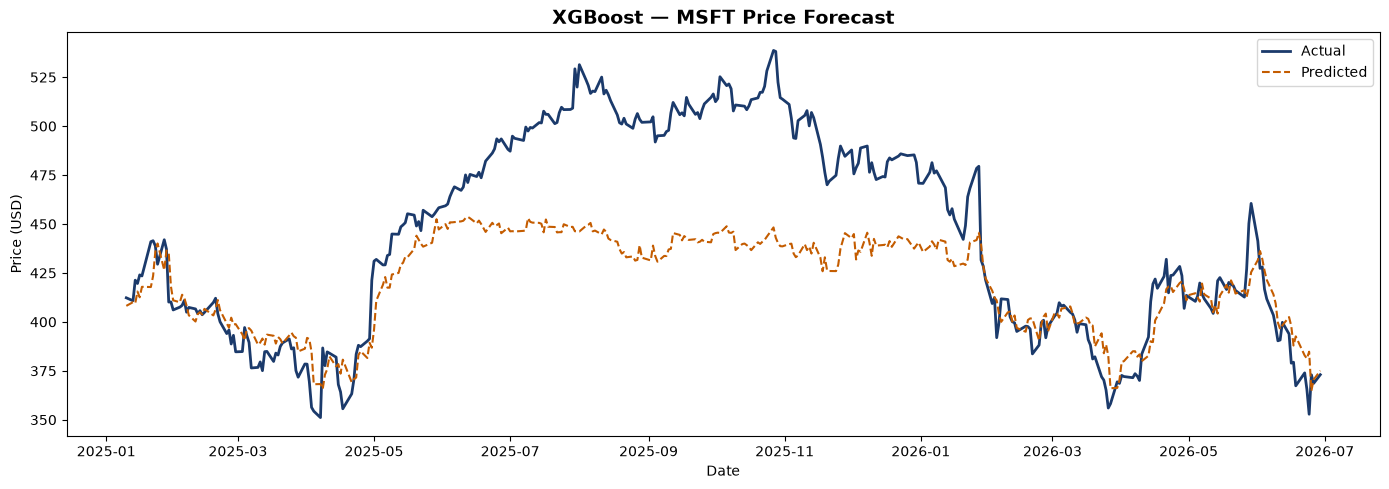

Chart saved to outputs/figures/MSFT_XGBoost.png

Training XGBoost on GOOGL...
GOOGL: loaded from cache (1883 rows)

  XGBoost — GOOGL
  RMSE               : 97.5234
  MAE                : 70.7530
  MAPE               : 22.41%
  Directional Acc.   : 49.5%


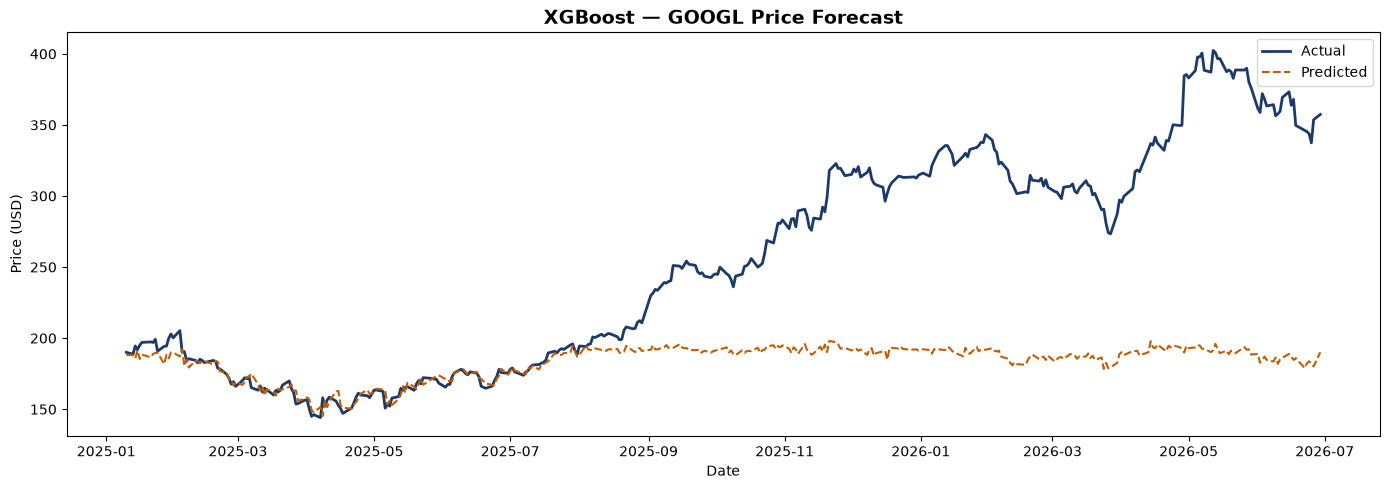

Chart saved to outputs/figures/GOOGL_XGBoost.png

Training XGBoost on TSLA...
TSLA: loaded from cache (1883 rows)

  XGBoost — TSLA
  RMSE               : 21.4272
  MAE                : 16.6151
  MAPE               : 4.32%
  Directional Acc.   : 46.7%


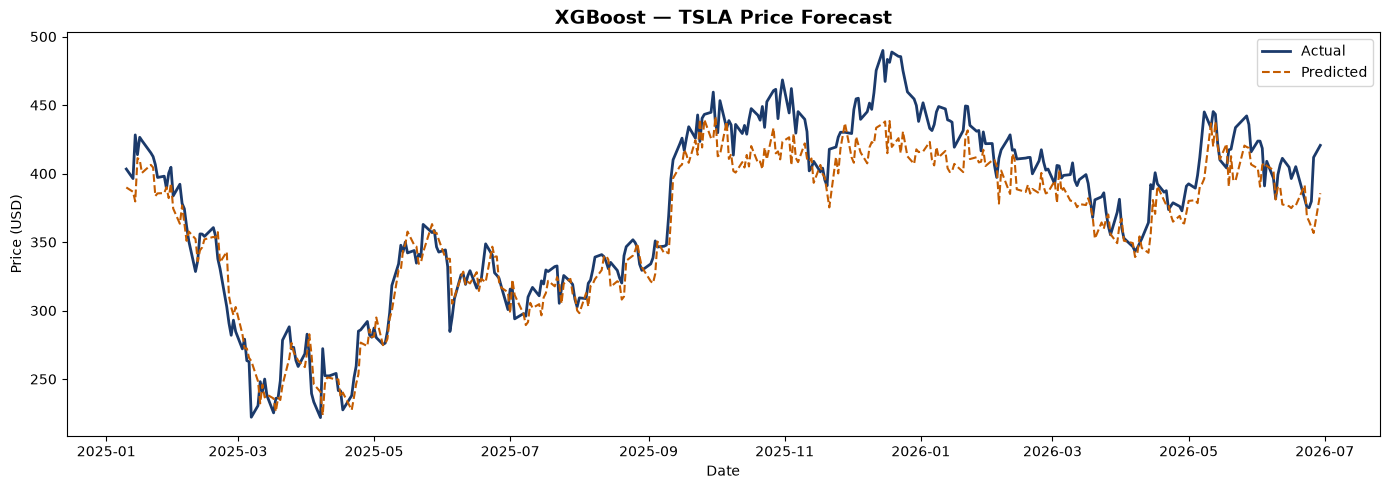

Chart saved to outputs/figures/TSLA_XGBoost.png

Training XGBoost on AMZN...
AMZN: loaded from cache (1883 rows)

  XGBoost — AMZN
  RMSE               : 15.3330
  MAE                : 10.5461
  MAPE               : 4.43%
  Directional Acc.   : 45.4%


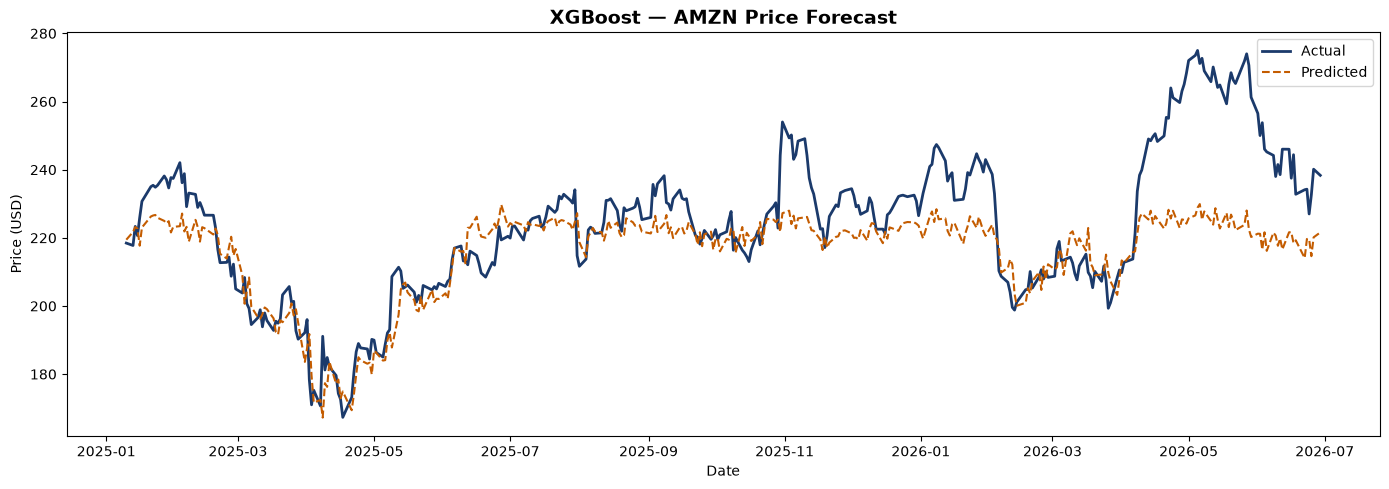

Chart saved to outputs/figures/AMZN_XGBoost.png
XGBoost complete.


In [1]:
import os
os.chdir(r'C:\Users\sande\Code\Personal\Python\DataScience\Project_3')

import sys
sys.path.append('..')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from src.data_loader import fetch_ticker, TICKERS
from src.features import prepare_xgboost_data
from src.evaluate import compute_metrics, plot_predictions
import warnings
warnings.filterwarnings('ignore')
 
all_results = []
 
for ticker in TICKERS:
    print(f'\nTraining XGBoost on {ticker}...')
 
    df = fetch_ticker(ticker)
    X, y, dates = prepare_xgboost_data(df)
 
    # Time-series split — NEVER shuffle stock data
    # Use last 20% as test set
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    test_dates      = dates[split_idx:]
 
    # Scale features
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
 
    # Train XGBoost
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
 
    # Predict and evaluate
    y_pred  = model.predict(X_test)
    metrics = compute_metrics(y_test.values, y_pred, 'XGBoost', ticker)
    all_results.append(metrics)
 
    # Plot
    plot_predictions(test_dates, y_test.values, y_pred, 'XGBoost', ticker)
 
    # Feature importance for AAPL
    if ticker == 'AAPL':
        feat_names = ['MA_7','MA_21','MA_50','MA_cross','BB_width',
                      'RSI','MACD','MACD_hist','Lag1','Lag5',
                      'DailyRet','WeeklyRet','VolRatio']
        importance = pd.Series(model.feature_importances_, index=feat_names)
        importance.sort_values().plot(kind='barh', color='#2E75B6',
                                      figsize=(8, 5))
        plt.title('XGBoost Feature Importance — AAPL', fontweight='bold')
        plt.tight_layout()
        plt.savefig('outputs/figures/xgb_feature_importance.png', dpi=150)
        plt.show()
 
# Save
pd.DataFrame(all_results).to_csv('outputs/results/xgboost_results.csv', index=False)
print('XGBoost complete.')
